# AI651 – PA-1, Task 2: Autoformer

**Plan**

1. Data analysis 
2. Design decisions derived from (1).
3. Autoformer implementation (series decomposition + auto-correlation, encoder–decoder).
4. Chronological backtest over many 168-step blocks, several seeds, with/without-external-data ablation.
5. Final refit, seed averaged forecast

Run with `QUICK = True` first for smoke test that everything runs; set `QUICK = False` for the
evidence for the report.

In [ ]:
import os, math, json, random, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})

ROOT = Path(".").resolve()
DATA = ROOT / "Data"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

QUICK = False            # True: fast smoke run. False: full evidence run for the report.
PRED_LEN = 168          # fixed by the assignment

## 1. Load and sanity-check the data

In [ ]:
train = pd.read_csv(DATA / "student_train.csv")
test = pd.read_csv(DATA / "student_test.csv")
ext = pd.read_csv(DATA / "optional_external_data.csv")

N = len(train)
assert list(train.columns) == ["time_idx", "value"]
assert (train.time_idx.values == np.arange(1, N + 1)).all(), "train index must be 1..N contiguous"
assert len(ext) == N + PRED_LEN and (ext.time_idx.values == np.arange(1, N + PRED_LEN + 1)).all()
assert test.time_idx.min() == N + 1 and test.time_idx.max() == N + PRED_LEN
assert train.value.isna().sum() == 0 and ext.isna().sum().sum() == 0

y = train.value.values.astype(np.float64)
print(f"train rows {N:,}   test rows {len(test)}   external rows {len(ext):,}")
print(f"value: min {y.min():.0f}  median {np.median(y):.0f}  mean {y.mean():.1f}  "
      f"std {y.std():.1f}  max {y.max():.0f}  zeros {(y == 0).sum()}")
print(f"{N + PRED_LEN} / 8760 = {(N + PRED_LEN) / 8760:.4f}  ->  five years of hourly data plus one leap day")
ext.describe().T.round(2)

train rows 43,656   test rows 168   external rows 43,824
value: min 0  median 73  mean 98.2  std 90.8  max 994  zeros 2
43824 / 8760 = 5.0027  ->  five years of hourly data plus one leap day


,count,mean,std,min,25%,50%,75%,max
time_idx,43824.0,21912.50,12651.04,1.00,10956.75,21912.50,32868.25,43824.0
feature_A,43824.0,1.82,14.43,-40.00,-10.00,2.00,15.00,28.0
feature_B,43824.0,12.45,12.20,-19.00,2.00,14.00,23.00,42.0
feature_C,43824.0,1016.45,10.27,991.00,1008.00,1016.00,1025.00,1046.0
feature_D,43824.0,23.89,50.01,0.45,1.79,5.37,21.91,585.6
feature_E,43824.0,0.05,0.76,0.00,0.00,0.00,0.00,27.0
feature_F,43824.0,0.19,1.42,0.00,0.00,0.00,0.00,36.0
feature_G,43824.0,0.11,0.32,0.00,0.00,0.00,0.00,1.0
feature_H,43824.0,0.32,0.47,0.00,0.00,0.00,1.00,1.0
feature_I,43824.0,0.35,0.48,0.00,0.00,0.00,1.00,1.0


**Observation.** 43,824 = 5 × 8,760 + 24: the sampling interval is almost certainly one hour and the
record is five calendar years including one leap day. The target is non-negative, right-skewed
(median 73, mean 98, max 994) and heavy-tailed, as the assignment warned.

## 2. Data analysis

### 2.1 The series at three different intervals

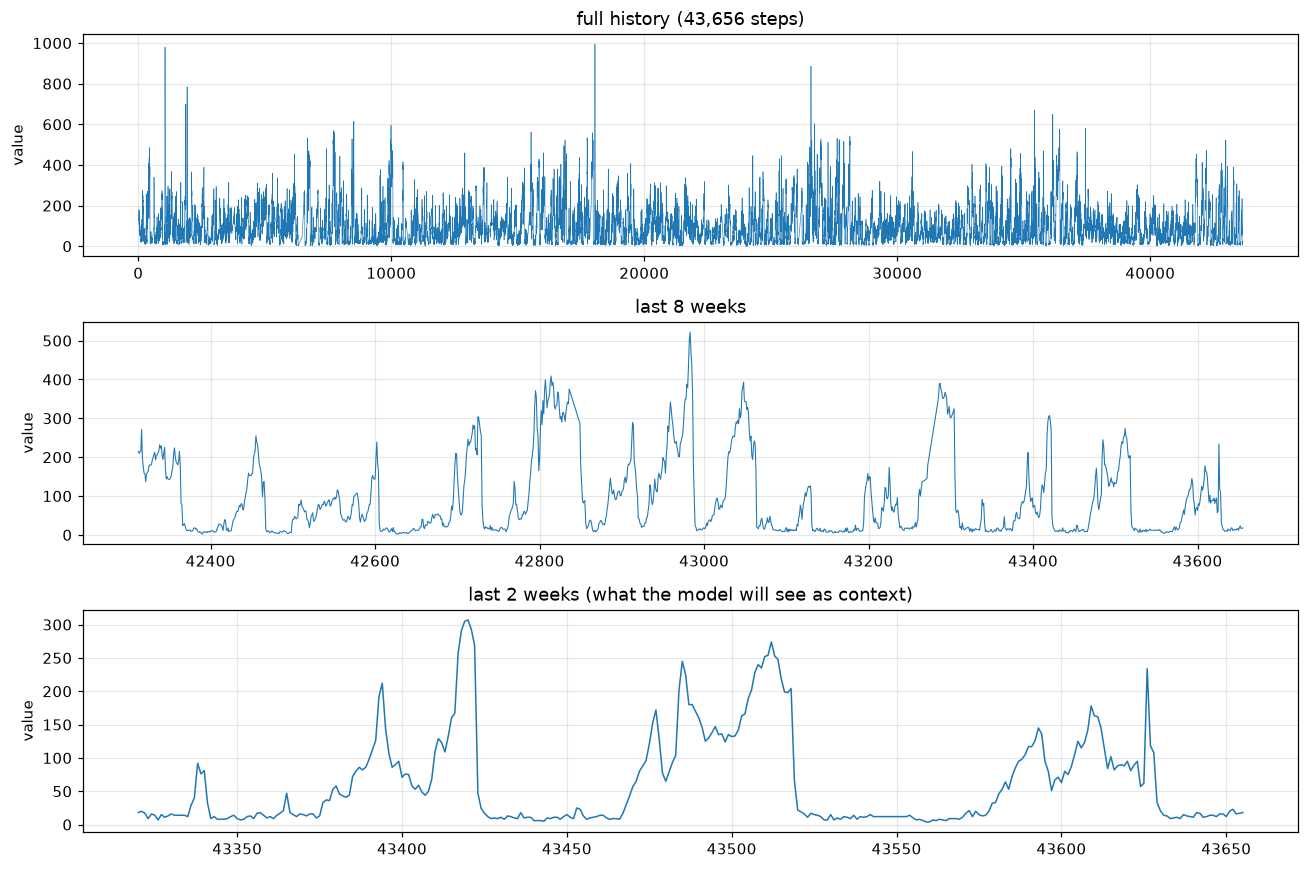

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8))
ax[0].plot(y, lw=.4); ax[0].set_title("full history (43,656 steps)")
ax[1].plot(np.arange(N - 24 * 7 * 8, N), y[-24 * 7 * 8:], lw=.7); ax[1].set_title("last 8 weeks")
ax[2].plot(np.arange(N - 24 * 7 * 2, N), y[-24 * 7 * 2:], lw=1); ax[2].set_title("last 2 weeks (what the model will see as context)")
for a in ax: a.set_ylabel("value")
plt.tight_layout(); plt.savefig(OUT / "fig_t2_01_series.pdf"); plt.show()

### 2.2 Distribution and the case for a log transform

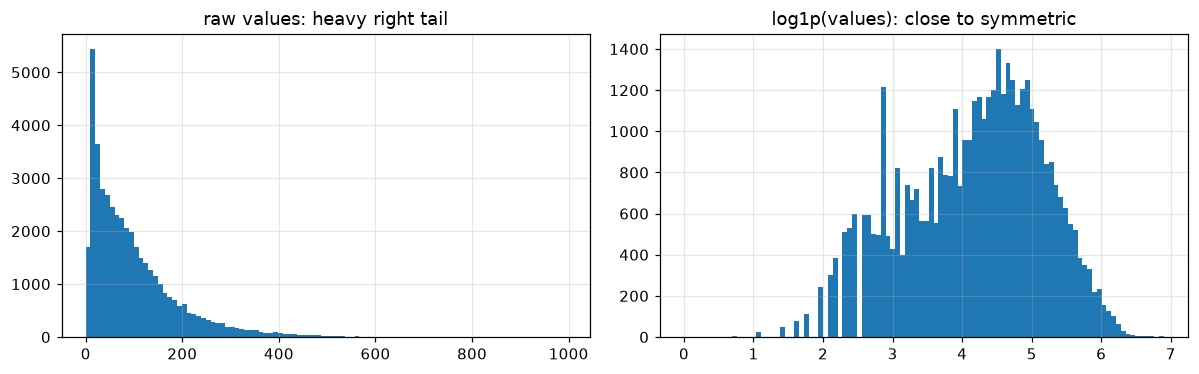

skewness raw 1.83   log1p -0.32


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(y, bins=100); ax[0].set_title("raw values: heavy right tail")
ax[1].hist(np.log1p(y), bins=100); ax[1].set_title("log1p(values): close to symmetric")
plt.tight_layout(); plt.savefig(OUT / "fig_t2_02_distribution.pdf"); plt.show()
print("skewness raw %.2f   log1p %.2f" % (pd.Series(y).skew(), pd.Series(np.log1p(y)).skew()))

**Decision 1.** Train in `log1p` space (symmetric residuals, non-negativity guaranteed after `expm1`),
but *select* models on raw-scale RMSE because that is what the leaderboard scores. A logspace model
optimises relative error and can under predict the spikes; the backtest will tell us whether that costs
more than it saves.

### 2.3 How long is the series' memory? Autocorrelation and periodogram

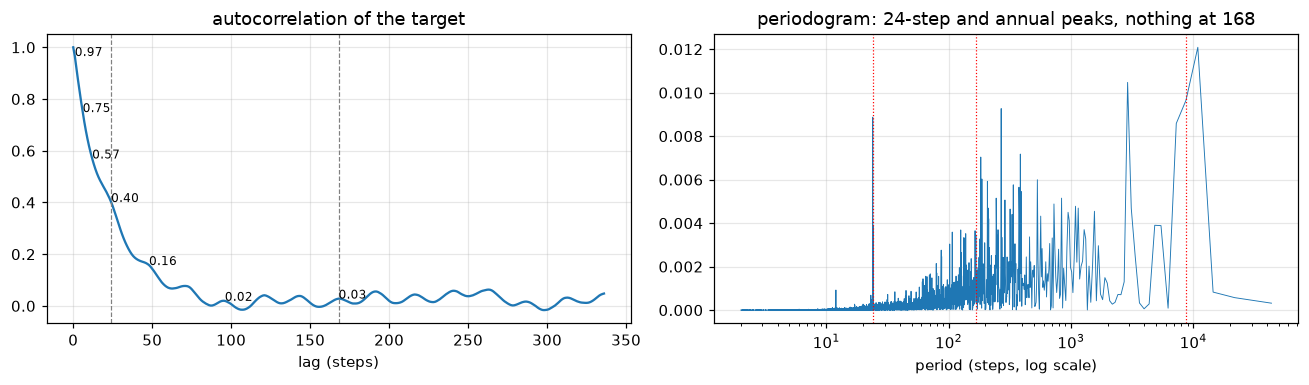

{1: np.float64(0.966), 2: np.float64(0.92), 3: np.float64(0.874), 6: np.float64(0.749), 12: np.float64(0.57), 24: np.float64(0.401), 48: np.float64(0.158), 72: np.float64(0.077), 96: np.float64(0.019), 168: np.float64(0.028), 336: np.float64(0.048)}


In [ ]:
def acf(x, max_lag):
    x = x - x.mean(); d = (x * x).sum()
    return np.array([(x[:-l] * x[l:]).sum() / d if l else 1.0 for l in range(max_lag + 1)])

lags = 24 * 14
a = acf(y, lags)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(a); ax[0].axvline(24, c="gray", ls="--", lw=.8); ax[0].axvline(168, c="gray", ls="--", lw=.8)
ax[0].set_xlabel("lag (steps)"); ax[0].set_title("autocorrelation of the target")
for l in [1, 6, 12, 24, 48, 96, 168]: ax[0].annotate(f"{a[l]:.2f}", (l, a[l]), fontsize=8)

f = np.fft.rfftfreq(N); p = np.abs(np.fft.rfft(y - y.mean())) ** 2
mask = f > 0
ax[1].plot(1 / f[mask], p[mask] / p.sum(), lw=.6); ax[1].set_xscale("log")
for per in [24, 168, 8766]: ax[1].axvline(per, c="r", ls=":", lw=.8)
ax[1].set_xlabel("period (steps, log scale)"); ax[1].set_title("periodogram: 24-step and annual peaks, nothing at 168")
plt.tight_layout(); plt.savefig(OUT / "fig_t2_03_acf_periodogram.pdf"); plt.show()
print({l: round(a[l], 3) for l in [1, 2, 3, 6, 12, 24, 48, 72, 96, 168, 336]})

**Observation.** Autocorrelation is 0.97 at lag 1, 0.40 at lag 24 and essentially zero beyond ~96
steps. A 168-step horizon is therefore mostly *beyond the series' own memory*: after the first day or
two the best point forecast is not a continuation of the recent pattern but the conditional mean given
whatever external conditions prevail. The periodogram shows a daily (24) cycle and annual power, and no
weekly (168) cycle.

**Decision 2.** The decomposition kernel should be about one daily cycle (25), the delay band of the
auto-correlation should be allowed to find 24, and the context length should cover ~two weeks (336),
not more: longer contexts add no memory here.

### 2.4 Daily profile recovered from the index (no calendar given)

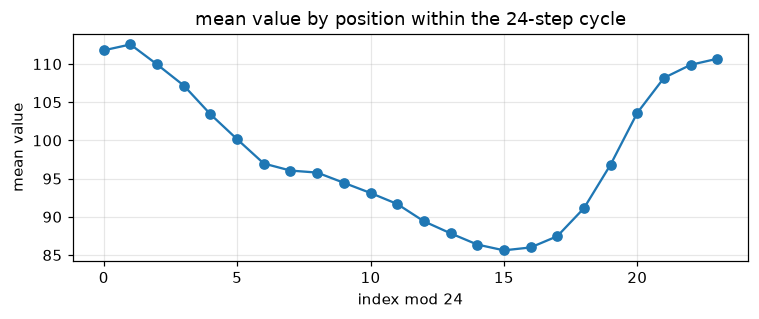

peak-to-trough of the daily profile: 26.9 (about 27% of the mean)


In [ ]:
hour = (np.arange(N)) % 24
prof = pd.Series(y).groupby(hour).mean()
plt.figure(figsize=(7, 3)); plt.plot(prof.index, prof.values, marker="o"); plt.xlabel("index mod 24"); plt.ylabel("mean value")
plt.title("mean value by position within the 24-step cycle"); plt.tight_layout(); plt.savefig(OUT / "fig_t2_04_daily_profile.pdf"); plt.show()
print("peak-to-trough of the daily profile: %.1f (about %.0f%% of the mean)" % (prof.max() - prof.min(), 100 * (prof.max() - prof.min()) / y.mean()))

**Decision 3.** Encode the daily and annual position as `sin/cos(2πt/24)` and `sin/cos(2πt/8766)`
computed from the integer index. Using both sine and cosine means the model can learn the phase itself,
so we do not need to know which index corresponds to midnight. These features are known over the
horizon and go into the decoder as well as the encoder. (Q2.8: this is what replaces calendar features.)

### 2.5 What the optional variables are

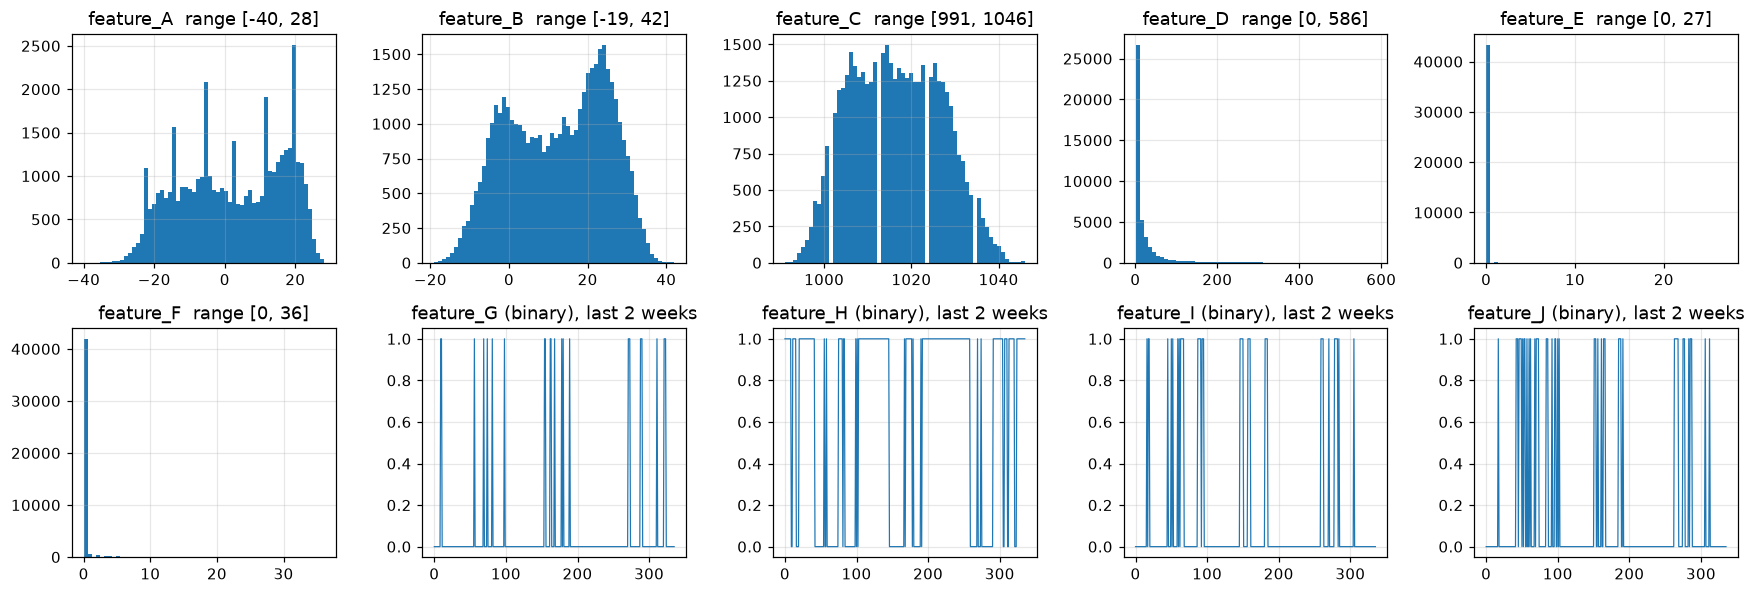

binary indicators mutually exclusive at every step: True


In [ ]:
cov_names = [c for c in ext.columns if c != "time_idx"]
E = ext[cov_names].values.astype(np.float64)
Ehist = E[:N]
fig, ax = plt.subplots(2, 5, figsize=(16, 5.5))
for i, c in enumerate(cov_names):
    a = ax.flat[i]
    if ext[c].nunique() <= 2:
        a.plot(Ehist[-24 * 14:, i], lw=.8); a.set_title(f"{c} (binary), last 2 weeks")
    else:
        a.hist(Ehist[:, i], bins=60); a.set_title(f"{c}  range [{Ehist[:, i].min():.0f}, {Ehist[:, i].max():.0f}]")
plt.tight_layout(); plt.savefig(OUT / "fig_t2_05_covariates.pdf"); plt.show()
print("binary indicators mutually exclusive at every step:", (Ehist[:, 6:10].sum(1) == 1).all())

**Observation.** The ranges read like hourly weather: A spans −21…28 (dew-point-like), B a temperature-like
range, C sits at ~1016 (pressure-like), D is a long-tailed non-negative quantity up to ~586 (a cumulative
wind-speed-like measure), E and F are small non-negative counts that are mostly zero (precipitation-hour-like),
and G–J are a one-hot of four categories (direction-like). The target then behaves like an hourly
concentration of something that disperses with wind. We only use this as physical intuition for *where*
each variable should enter the model; nothing outside the provided files is used.

### 2.6 Do the covariates carry signal about the target?

conditional mean of the target under each binary indicator:
  feature_G: share 0.11   mean value   89.9
  feature_H: share 0.32   mean value   70.2
  feature_I: share 0.35   mean value  110.2
  feature_J: share 0.21   mean value  125.0

mean target by quintile of feature_D:
(0.449, 1.78]     137.2
(1.78, 3.56]      110.5
(3.56, 9.83]      102.1
(9.83, 29.07]      85.6
(29.07, 585.6]     54.5


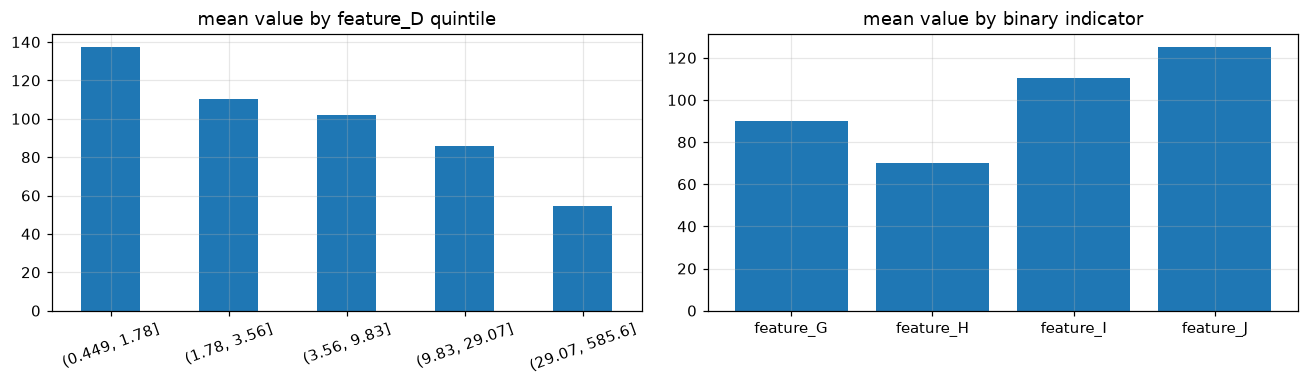

In [ ]:
cont = cov_names[:6]; binr = cov_names[6:]
print("conditional mean of the target under each binary indicator:")
for c in binr:
    m = Ehist[:, cov_names.index(c)] == 1
    print(f"  {c}: share {m.mean():.2f}   mean value {y[m].mean():6.1f}")
q = pd.qcut(Ehist[:, 3], 5, duplicates="drop")
print("\nmean target by quintile of feature_D:")
print(pd.Series(y).groupby(q, observed=True).mean().round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
pd.Series(y).groupby(q, observed=True).mean().plot.bar(ax=ax[0], rot=20); ax[0].set_title("mean value by feature_D quintile")
ax[1].bar(binr, [y[Ehist[:, cov_names.index(c)] == 1].mean() for c in binr]); ax[1].set_title("mean value by binary indicator")
plt.tight_layout(); plt.savefig(OUT / "fig_t2_06_conditional_means.pdf"); plt.show()

**Observation.** The target more than halves between the calmest and windiest quintile of D, and differs
by ~1.8× between indicators H and J. These are large effects relative to the target's own memory at
horizon 168. The question is *when* each covariate value is available.

### 2.7 Contemporaneous versus lagged covariate information
For a step `t+h` inside the horizon, a model can use either the covariate at `t+h` (known in advance,
provided in the file) or the covariate at the forecast origin `t` (history only). We compare how
informative each is as `h` grows.

In [ ]:
def corr_at_lead(x, cov, h):
    # corr(value[t+h], cov[t]) for all t
    return np.corrcoef(x[h:], cov[:len(cov) - h])[0, 1] if h else np.corrcoef(x, cov)[0, 1]

leads = [0, 6, 12, 24, 48, 96, 168]
rows = []
for c in ["feature_A", "feature_D", "feature_H", "feature_J"]:
    cov = Ehist[:, cov_names.index(c)]
    rows.append([c] + [round(corr_at_lead(np.log1p(y), cov, h), 3) for h in leads])
tab = pd.DataFrame(rows, columns=["covariate"] + [f"lead {h}" for h in leads]).set_index("covariate")
print("corr( log1p(value)[t+h] , covariate[t] )  — lead 0 is the contemporaneous value, i.e. what the horizon covariates provide")
tab

corr( log1p(value)[t+h] , covariate[t] )  — lead 0 is the contemporaneous value, i.e. what the horizon covariates provide


,lead 0,lead 6,lead 12,lead 24,lead 48,lead 96,lead 168
covariate,,,,,,,
feature_A,0.308,0.244,0.179,0.101,0.021,0.001,0.029
feature_D,-0.348,-0.301,-0.245,-0.153,-0.046,0.012,-0.031
feature_H,-0.346,-0.432,-0.356,-0.215,-0.042,0.006,-0.012
feature_J,0.182,0.183,0.134,0.099,0.024,0.003,0.009


**Observation.** The contemporaneous correlations (lead 0) are the ones a model with horizon covariates
can exploit at every step of the horizon. Using only the covariate value at the forecast origin, the
correlation decays with the lead and is near zero by 96–168 steps, like the target's own memory.

**Decision 4 (the key one).**
* Past covariates enter the **encoder** alongside the target.
* Horizon covariates enter the **decoder** (they are known for every step we forecast) and additionally
  feed a small, zero-initialised path onto the trend stream / output so the network can express
  "conditional mean given conditions" directly.
* The required ablation compares: no external data → time features only → history-only covariates →
  horizon covariates in the decoder → + direct covariate path.

### 2.8 The hidden week's conditions compared with the history
The external file covers the 168 hidden steps. Before modelling, look at what regime they describe.

           history mean  hidden-week mean  history std  z of hidden mean
feature_A          1.87            -13.03        14.43             -1.03
feature_B         12.50             -0.26        12.19             -1.05
feature_C       1016.41           1025.37        10.26              0.87
feature_D         23.85             33.16        49.96              0.19
feature_E          0.05              0.00         0.76             -0.07
feature_F          0.20              0.00         1.42             -0.14
feature_G          0.11              0.11         0.32              0.00
feature_H          0.32              0.52         0.47              0.43
feature_I          0.35              0.09         0.48             -0.54
feature_J          0.21              0.29         0.41              0.20


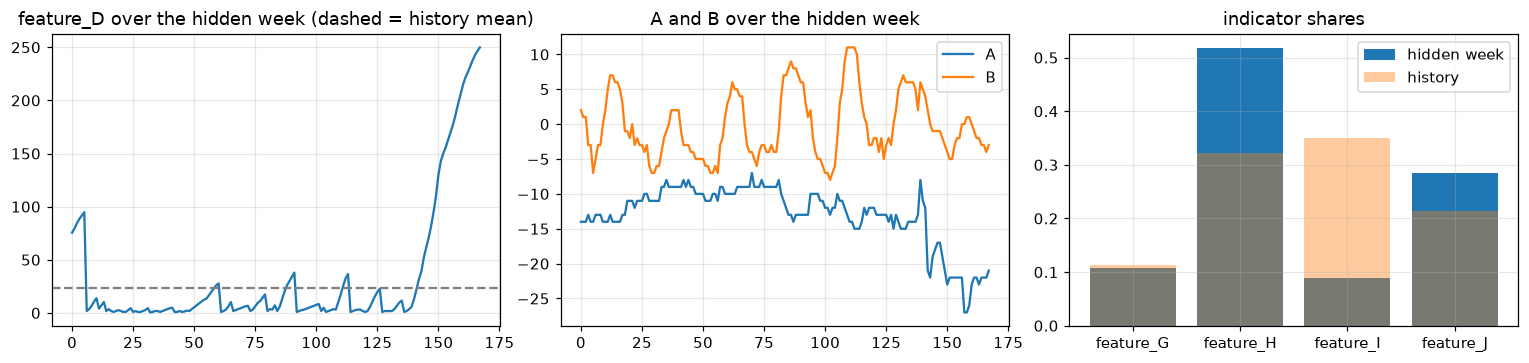

last 24 observed values: [13, 9, 10, 11, 9, 15, 13, 12, 11, 18, 17, 11, 12, 14, 14, 12, 16, 16, 12, 20, 23, 16, 17, 18]


In [ ]:
Ehid = E[N:]
comp = pd.DataFrame({
    "history mean": Ehist.mean(0), "hidden-week mean": Ehid.mean(0),
    "history std": Ehist.std(0)}, index=cov_names).round(2)
comp["z of hidden mean"] = ((comp["hidden-week mean"] - comp["history mean"]) / comp["history std"]).round(2)
print(comp.to_string())

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].plot(Ehid[:, 3]); ax[0].axhline(Ehist[:, 3].mean(), c="gray", ls="--"); ax[0].set_title("feature_D over the hidden week (dashed = history mean)")
ax[1].plot(Ehid[:, 0], label="A"); ax[1].plot(Ehid[:, 1], label="B"); ax[1].legend(); ax[1].set_title("A and B over the hidden week")
ax[2].bar(binr, Ehid[:, 6:10].mean(0), label="hidden week"); ax[2].bar(binr, Ehist[:, 6:10].mean(0), alpha=.4, label="history"); ax[2].legend(); ax[2].set_title("indicator shares")
plt.tight_layout(); plt.savefig(OUT / "fig_t2_07_hidden_week_covariates.pdf"); plt.show()
print("last 24 observed values:", y[-24:].astype(int).tolist())

**Observation.** The hidden week is windier than average (D well above its mean), dominated by indicator H
(the category associated with the lowest conditional mean), and cold/dry (A far below mean). The last
24 observed values are already low. Every available signal points to a low-level week with isolated
spikes where the indicator switches. A model that conditions on the horizon covariates can express that;
one that extrapolates the history alone will hedge toward the long-run mean (~98) and pay for it in RMSE.

### 2.9 How hard is the problem? Naive baselines on rolling 168-step blocks

In [ ]:
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mae(a, b): return float(np.mean(np.abs(a - b)))
def smape(a, b): return float(100 * np.mean(2 * np.abs(b - a) / (np.abs(a) + np.abs(b) + 1e-8)))

B = 40
base = {"last value": [], "mean of last 336": [], "global mean": []}
for k in range(1, B + 1):
    end = N - PRED_LEN * (k - 1); s = end - PRED_LEN
    tgt, hist = y[s:end], y[:s]
    base["last value"].append(rmse(tgt, hist[-1]))
    base["mean of last 336"].append(rmse(tgt, hist[-336:].mean()))
    base["global mean"].append(rmse(tgt, hist.mean()))
pd.DataFrame({k: {"mean RMSE": np.mean(v), "median": np.median(v), "std over blocks": np.std(v), "last block": v[0]} for k, v in base.items()}).T.round(1)

,mean RMSE,median,std over blocks,last block
last value,105.5,74.9,85.0,131.4
mean of last 336,74.6,57.2,35.2,71.7
global mean,75.4,63.6,31.1,76.9


**Observation.** Persistence is terrible (the series mean-reverts within a day), and a constant equal to
the recent mean is a strong baseline. The spread across blocks is enormous (std ≈ 35–100 RMSE), so a
single 168-step score says little about model quality: *every decision below is made on the average over
many blocks and several seeds*, never on one block.

### 2.10 Design summary

| decision | evidence | choice |
|---|---|---|
| target transform | heavy tail (2.2) | train on `log1p`, select on raw RMSE; also test raw-scale training |
| context / kernel | ACF, periodogram (2.3) | `seq_len=336`, `label_len=168`, decomposition kernel 25, delay budget `factor=2` |
| time features | daily + annual cycles (2.3, 2.4) | sin/cos of index at periods 24 and 8766, in encoder and decoder |
| external data | conditional means, lead analysis (2.6–2.7) | past → encoder; horizon → decoder + zero-init trend/output path; full ablation |
| level information | hidden week regime, low last day (2.8) | trend initialised from the last observations with learned decay; window normalisation tested as an ablation, not default |
| validation | block spread (2.9) | chronological backtest over the last ~year, non-overlapping 168-blocks, ≥3 seeds |
| loss | heavy tail | Huber in log space (≈MSE for small residuals, robust to spikes) |

## 3. Feature construction
All statistics come from the observed history only. The hidden-week covariates are transformed with the
same statistics (they are inputs, never targets).

In [ ]:
t_all = np.arange(N + PRED_LEN)
time_feats = np.stack([np.sin(2 * np.pi * t_all / 24), np.cos(2 * np.pi * t_all / 24),
                       np.sin(2 * np.pi * t_all / 8766), np.cos(2 * np.pi * t_all / 8766)], 1).astype(np.float32)

# Trailing rolling means of the most informative covariates (6 h and 24 h). They are functions of past
# covariate values only, so they are known over the horizon exactly like the raw covariates are.
def trailing_mean(a, w): return pd.Series(a).rolling(w, min_periods=1).mean().values
roll_src = [cov_names.index(c) for c in ["feature_D", "feature_A", "feature_H", "feature_J"]]
roll_feats = np.stack([trailing_mean(E[:, j], w) for j in roll_src for w in (6, 24)], 1)   # [N+168, 8]
roll_names = [f"{cov_names[j]}_mean{w}" for j in roll_src for w in (6, 24)]

E_aug = np.concatenate([E, roll_feats], 1)                     # [N+168, 18]
cont_idx = list(range(6)) + list(range(10, 18))                # continuous: A-F and the 8 rolling means
mu, sd = E_aug[:N, cont_idx].mean(0), E_aug[:N, cont_idx].std(0) + 1e-6
E_scaled = E_aug.copy()
E_scaled[:, cont_idx] = (E_aug[:, cont_idx] - mu) / sd
E_scaled = E_scaled.astype(np.float32)

N_WEATHER, N_TIME = E_scaled.shape[1], time_feats.shape[1]
FEATS = np.concatenate([E_scaled, time_feats], 1)              # [N+168, 22]: 0-17 weather (+rolling), 18-21 time

# two target spaces: log1p (symmetric residuals) and raw divided by the training std (RMSE-aligned)
y_log = np.log1p(y).astype(np.float32)
Y_SCALE = float(y.std())
y_raw_s = (y / Y_SCALE).astype(np.float32)
SQRT_SCALE = float(np.sqrt(y).std())
y_sqrt_s = (np.sqrt(y) / SQRT_SCALE).astype(np.float32)   # between log (median-like) and raw (mean-like)
TARGET = {"log": y_log, "raw": y_raw_s, "sqrt": y_sqrt_s}
print("feature matrix", FEATS.shape, "| weather columns 0..17 (10 given + 8 rolling), time columns 18..21")

feature matrix (43824, 22) | weather columns 0..17 (10 given + 8 rolling), time columns 18..21


## 4. Autoformer

Written from scratch following Wu et al. (2021) §3.1–3.2 and the layer layout of the official
implementation (github.com/thuml/Autoformer), and descended from the delay mixer / decomposition built in
Task 1. It contains the two mechanisms required by §2.4:

* **Series decomposition** – centered moving average with edge replication, applied after every
  sublayer in encoder and decoder (progressive decomposition), with trends accumulated through the decoder.
* **Auto-correlation** – delay scores `R(τ)=Σ_t q_t k_{t−τ}` for all τ by FFT, top-`k=⌈factor·log L⌉`
  delays per example, softmax weights, aggregation of circularly shifted values.

Deviations from the reference, all deliberate: per-example delay selection (reference selects per batch in
training); aggregation reads `v[t−τ]`, consistent with the score definition and with Task 1 eq. (6);
`ceil` instead of `int` in `k`; no calendar embedding (covariates are extra conv channels); known-future
covariates enter the decoder embedding; a `memory_align="last"` option so a long encoder keeps its most
recent positions in cross-correlation; the decoder trend is initialised from the last observations and
relaxed toward the window mean with a learned time constant instead of the paper's mean placeholder; and
optional zero-initialised covariate paths onto the trend stream and the output.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.deterministic = True      # removes one source of run-to-run variance; CUDA FFT/gather remain non-deterministic
torch.backends.cudnn.benchmark = False
print("device:", DEVICE)


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        assert kernel % 2 == 1 and kernel > 0
        self.kernel = kernel
    def forward(self, x):                                   # [B, L, C] -> (seasonal, trend)
        r = self.kernel // 2
        s = x.transpose(1, 2)
        if r: s = F.pad(s, (r, r), mode="replicate")
        trend = F.avg_pool1d(s, self.kernel, stride=1).transpose(1, 2)
        return x - trend, trend


class SeasonalNorm(nn.Module):
    def __init__(self, d):
        super().__init__(); self.norm = nn.LayerNorm(d)
    def forward(self, x):
        y = self.norm(x); return y - y.mean(1, keepdim=True)


class RevIN(nn.Module):
    def __init__(self, eps=1e-5):
        super().__init__(); self.eps = eps
        self.weight = nn.Parameter(torch.ones(1)); self.bias = nn.Parameter(torch.zeros(1))
    def normalize(self, x):
        self.mean = x.mean(1, keepdim=True).detach()
        self.std = (x.var(1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()
        return (x - self.mean) / self.std * self.weight + self.bias
    def denormalize(self, y):
        return (y - self.bias) / (self.weight + self.eps) * self.std + self.mean


class AutoCorrelation(nn.Module):
    def __init__(self, d_model, n_heads, factor=1.0, dropout=0.1, memory_align="first",
                 share_qk=False, temperature=False):
        super().__init__()
        assert d_model % n_heads == 0 and memory_align in {"first", "last"}
        self.heads, self.factor, self.memory_align = n_heads, factor, memory_align
        self.query = nn.Linear(d_model, d_model)
        self.key = self.query if share_qk else nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        self.log_temperature = nn.Parameter(torch.zeros(1)) if temperature else None
        self.last_delays = None

    @staticmethod
    def delay_scores(q, k):                                 # [B,h,d,L] -> [B,L]
        spec = torch.fft.rfft(q, dim=-1) * torch.fft.rfft(k, dim=-1).conj()
        return torch.fft.irfft(spec, n=q.shape[-1], dim=-1).mean((1, 2))

    @staticmethod
    def aggregate(values, delays, weights):                 # values [B,h,d,L]; delays/weights [B,K]
        B_, h, d, L = values.shape
        pos = torch.arange(L, device=values.device)
        src = (pos[None, None, :] - delays[:, :, None]) % L
        idx = src[:, :, None, None, :].expand(-1, -1, h, d, -1)
        gathered = values.unsqueeze(1).expand(-1, delays.shape[1], -1, -1, -1)
        shifted = torch.gather(gathered, -1, idx)
        return (weights.to(values.dtype)[:, :, None, None, None] * shifted).sum(1)

    def forward(self, queries, keys, values):
        B_, Lq, W = queries.shape; Lk = keys.shape[1]
        hs = lambda x, L: x.view(B_, L, self.heads, W // self.heads).permute(0, 2, 3, 1)
        q, k, v = hs(self.query(queries), Lq), hs(self.key(keys), Lk), hs(self.value(values), Lk)
        if Lk > Lq:
            k, v = (k[..., :Lq], v[..., :Lq]) if self.memory_align == "first" else (k[..., -Lq:], v[..., -Lq:])
        elif Lk < Lq:
            k, v = F.pad(k, (0, Lq - Lk)), F.pad(v, (0, Lq - Lk))
        scores = self.delay_scores(q, k)
        top_k = max(1, min(int(math.ceil(self.factor * math.log(Lq))), Lq))
        sel, delays = scores.topk(top_k, dim=-1)
        if self.log_temperature is not None: sel = sel / self.log_temperature.exp()
        w = sel.softmax(-1)
        self.last_delays = delays.detach()
        mixed = self.aggregate(v, delays, w).permute(0, 3, 1, 2).reshape(B_, Lq, W)
        return self.drop(self.out(mixed))


def feed_forward(d_model, d_ff, dropout):
    return nn.Sequential(nn.Conv1d(d_model, d_ff, 1, bias=False), nn.GELU(), nn.Dropout(dropout),
                         nn.Conv1d(d_ff, d_model, 1, bias=False))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, kernel, factor, dropout, share_qk, temperature):
        super().__init__()
        self.corr = AutoCorrelation(d_model, n_heads, factor, dropout, share_qk=share_qk, temperature=temperature)
        self.dec1, self.dec2 = SeriesDecomposition(kernel), SeriesDecomposition(kernel)
        self.ff = feed_forward(d_model, d_ff, dropout); self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x, _ = self.dec1(x + self.corr(x, x, x))
        x, _ = self.dec2(x + self.drop(self.ff(x.transpose(1, 2)).transpose(1, 2)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, kernel, factor, dropout, memory_align, share_qk, temperature, conv_padding="circular"):
        super().__init__()
        self.self_corr = AutoCorrelation(d_model, n_heads, factor, dropout, share_qk=share_qk, temperature=temperature)
        self.cross_corr = AutoCorrelation(d_model, n_heads, factor, dropout, memory_align, share_qk, temperature)
        self.dec1, self.dec2, self.dec3 = (SeriesDecomposition(kernel) for _ in range(3))
        self.ff = feed_forward(d_model, d_ff, dropout); self.drop = nn.Dropout(dropout)
        self.trend_proj = nn.Conv1d(d_model, 1, 3, padding=1, padding_mode=conv_padding, bias=False)
    def forward(self, x, memory):
        x, t1 = self.dec1(x + self.self_corr(x, x, x))
        x, t2 = self.dec2(x + self.cross_corr(x, memory, memory))
        x, t3 = self.dec3(x + self.drop(self.ff(x.transpose(1, 2)).transpose(1, 2)))
        return x, self.trend_proj((t1 + t2 + t3).transpose(1, 2)).transpose(1, 2)


def zero_init_head(n_in, hidden):
    if hidden:
        head = nn.Sequential(nn.Linear(n_in, hidden), nn.GELU(), nn.Linear(hidden, 1)); last = head[-1]
    else:
        head = nn.Linear(n_in, 1); last = head
    nn.init.zeros_(last.weight); nn.init.zeros_(last.bias)
    return head


class Autoformer(nn.Module):
    def __init__(self, seq_len=336, label_len=168, pred_len=168, n_cov=0, d_model=32, n_heads=4, d_ff=64,
                 e_layers=1, d_layers=1, kernel=25, factor=2.0, dropout=0.1, trend_init="decay-last",
                 anchor_window=6, memory_align="first", revin=False, cov_trend=False, cov_trend_hidden=0,
                 cov_skip=False, cov_skip_hidden=0, share_qk=False, temperature=False,
                 persist_blend=False, conv_padding="circular"):
        super().__init__()
        # persist_blend: out_h = w_h * y_last + (1 - w_h) * out_h with w_h = exp(-(h+1)/tau_p), tau_p learned (init 12).
        # One parameter, applied last, so the forecast starts from the last observation and hands over to the network.
        # persist_blend=True learns tau_p (init 12 h); persist_blend=<number> fixes tau_p at that many hours (buffer, no parameter)
        # self.log_tau_p = None
        # if persist_blend is True:
        #     self.log_tau_p = nn.Parameter(torch.tensor(math.log(12.0)))
        # elif persist_blend:
        #     self.register_buffer("log_tau_p", torch.tensor(math.log(float(persist_blend))))
        if persist_blend is True:
            self.log_tau_p = nn.Parameter(torch.tensor(math.log(12.0)))
        elif persist_blend:
            self.register_buffer("log_tau_p", torch.tensor(math.log(float(persist_blend))))
        else:
            self.register_buffer("log_tau_p", None)
        assert trend_init in {"mean", "decay", "decay-last"} and 1 <= anchor_window <= label_len <= seq_len
        self.seq_len, self.label_len, self.pred_len, self.n_cov = seq_len, label_len, pred_len, n_cov
        self.trend_init, self.anchor_window = trend_init, anchor_window
        self.log_tau = nn.Parameter(torch.tensor(math.log(48.0))) if trend_init != "mean" else None
        self.revin = RevIN() if revin else None
        self.decomp = SeriesDecomposition(kernel)
        self.cov_trend = zero_init_head(n_cov, cov_trend_hidden) if (cov_trend and n_cov) else None
        self.cov_skip = zero_init_head(n_cov, cov_skip_hidden) if (cov_skip and n_cov) else None
        self.enc_embedding = nn.Conv1d(1 + n_cov, d_model, 3, padding=1, padding_mode=conv_padding, bias=False)
        self.dec_embedding = nn.Conv1d(1 + n_cov, d_model, 3, padding=1, padding_mode=conv_padding, bias=False)
        for c in (self.enc_embedding, self.dec_embedding):
            nn.init.kaiming_normal_(c.weight, mode="fan_in", nonlinearity="leaky_relu")
        self.embed_dropout = nn.Dropout(dropout)
        self.encoder = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, kernel, factor, dropout, share_qk, temperature) for _ in range(e_layers)])
        self.encoder_norm = SeasonalNorm(d_model)
        self.decoder = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, kernel, factor, dropout, memory_align, share_qk, temperature, conv_padding) for _ in range(d_layers)])
        self.decoder_norm = SeasonalNorm(d_model)
        self.seasonal_proj = nn.Linear(d_model, 1)

    def _decoder_init(self, target):                        # target [B, seq_len, 1]
        s_full, t_full = self.decomp(target)                # decompose the whole input, then slice
        s_init, t_init = s_full[:, -self.label_len:], t_full[:, -self.label_len:]
        mean = target.mean(1, keepdim=True).expand(-1, self.pred_len, -1)
        if self.trend_init == "mean":
            horizon = mean
        else:
            steps = torch.arange(1, self.pred_len + 1, device=target.device, dtype=target.dtype)
            w = torch.exp(-steps / self.log_tau.exp())[None, :, None]
            anchor = t_init[:, -1:] if self.trend_init == "decay" else target[:, -self.anchor_window:].mean(1, keepdim=True)
            horizon = mean + w * (anchor - mean)
        return torch.cat([s_init, torch.zeros_like(mean)], 1), torch.cat([t_init, horizon], 1)

    def forward(self, x_enc, x_dec_cov=None):
        target = x_enc[..., :1]
        if self.revin is not None:
            target = self.revin.normalize(target); x_enc = torch.cat([target, x_enc[..., 1:]], -1)
        s_init, t_init = self._decoder_init(target)
        if self.n_cov:
            dec_in = torch.cat([s_init, x_dec_cov], -1)
            if self.cov_trend is not None: t_init = t_init + self.cov_trend(x_dec_cov)
        else:
            dec_in = s_init
        enc = self.embed_dropout(self.enc_embedding(x_enc.transpose(1, 2)).transpose(1, 2))
        for layer in self.encoder: enc = layer(enc)
        enc = self.encoder_norm(enc)
        dec = self.embed_dropout(self.dec_embedding(dec_in.transpose(1, 2)).transpose(1, 2))
        trend = t_init
        for layer in self.decoder:
            dec, rt = layer(dec, enc); trend = trend + rt
        out = (self.seasonal_proj(self.decoder_norm(dec)) + trend)[:, -self.pred_len:]
        if self.cov_skip is not None: out = out + self.cov_skip(x_dec_cov[:, -self.pred_len:])
        if self.log_tau_p is not None:                      # blend with the last observation (same space as out)
            steps = torch.arange(1, self.pred_len + 1, device=out.device, dtype=out.dtype)
            w = torch.exp(-steps / self.log_tau_p.exp())[None, :, None]
            out = w * target[:, -1:] + (1 - w) * out
        if self.revin is not None: out = self.revin.denormalize(out)
        return out                                          # [B, pred_len, 1] in model space


def count_parameters(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

# smoke test
_m = Autoformer(n_cov=14, cov_skip=True, cov_skip_hidden=16, persist_blend=True, conv_padding="replicate")
_x = torch.randn(2, 336, 15); _c = torch.randn(2, 336, 14)
assert _m(_x, _c).shape == (2, 168, 1)
print("Autoformer OK, parameters with 14 covariates:", f"{count_parameters(_m):,}")

device: cuda
Autoformer OK, parameters with 14 covariates: 24,260


## 5. Windows, training loop, metrics

A window at origin `o` gives the encoder `[y_log, feats]` over `[o−seq_len, o)`, the decoder the features
over `[o−label_len, o+pred_len)` and the target `y_log[o : o+pred_len]`. The `cov_mode` controls the
ablation arm:

| `cov_mode` | encoder input | decoder input |
|---|---|---|
| `none` | target only | nothing (seasonal init only) |
| `time` | target + time features | time features |
| `hist` | target + weather + time | time features; **weather zeroed over the horizon** (history-only use of the file) |
| `full` | target + weather + time | weather + time over label and horizon |

"weather" = the 10 given columns plus 8 trailing rolling means (6 h, 24 h of D, A, H, J). `space` selects the
target transform: `log` (train on `log1p`) or `raw` (train on value / training std, MSE loss).

In [ ]:
def feature_columns(cov_mode):
    if cov_mode == "none": return []
    if cov_mode == "time": return list(range(N_WEATHER, N_WEATHER + N_TIME))
    return list(range(N_WEATHER + N_TIME))                   # hist, full


class WindowDataset(torch.utils.data.Dataset):
    def __init__(self, origins, cols, seq_len, label_len, pred_len, mask_horizon_weather=False, with_target=True, space="log"):
        self.o = np.asarray(origins); self.cols = cols; self.yt = TARGET[space]
        self.seq, self.lab, self.pred = seq_len, label_len, pred_len
        self.mask, self.with_target = mask_horizon_weather, with_target
        self.F = FEATS[:, cols] if cols else np.zeros((len(FEATS), 0), np.float32)
    def __len__(self): return len(self.o)
    def __getitem__(self, i):
        o = int(self.o[i])
        enc = np.concatenate([self.yt[o - self.seq:o, None], self.F[o - self.seq:o]], 1)
        dec = self.F[o - self.lab:o + self.pred].copy()
        if self.mask: dec[self.lab:, :N_WEATHER] = 0.0      # horizon weather withheld
        tgt = np.ascontiguousarray(self.yt[o:o + self.pred, None]) if self.with_target else np.zeros((self.pred, 1), np.float32)
        return torch.from_numpy(enc), torch.from_numpy(dec), torch.from_numpy(tgt)


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


def build_model(cfg):
    cols = feature_columns(cfg["cov_mode"])
    kw = {k: v for k, v in cfg.items() if k not in {"name", "cov_mode", "epochs", "lr", "batch", "stride", "loss", "space"}}
    return Autoformer(n_cov=len(cols), pred_len=PRED_LEN, **kw), cols


def train_model(cfg, train_origins, seed, verbose=False):
    set_seed(seed)
    model, cols = build_model(cfg); model.to(DEVICE)
    ds = WindowDataset(train_origins[::cfg["stride"]], cols, cfg["seq_len"], cfg["label_len"], PRED_LEN,
                       mask_horizon_weather=(cfg["cov_mode"] == "hist"), space=cfg["space"])
    dl = torch.utils.data.DataLoader(ds, batch_size=cfg["batch"], shuffle=True, drop_last=True, num_workers=0)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg["lr"], total_steps=cfg["epochs"] * len(dl), pct_start=0.2)
    loss_fn = nn.HuberLoss(delta=1.0) if cfg["loss"] == "huber" else nn.MSELoss()
    t0 = time.time()
    for ep in range(cfg["epochs"]):
        model.train(); tot = 0.0
        for enc, dec, tgt in dl:
            enc, dec, tgt = enc.to(DEVICE), dec.to(DEVICE), tgt.to(DEVICE)
            pred = model(enc, dec if cols else None)
            loss = loss_fn(pred, tgt)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step()
            tot += loss.item() * len(enc)
        if verbose: print(f"  epoch {ep + 1}/{cfg['epochs']}  train loss {tot / len(ds):.4f}  ({time.time() - t0:.0f}s)")
    return model, cols


@torch.no_grad()
def predict(model, cols, cfg, origins, mask):
    model.eval()
    ds = WindowDataset(origins, cols, cfg["seq_len"], cfg["label_len"], PRED_LEN, mask_horizon_weather=mask, with_target=False, space=cfg["space"])
    dl = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=False)
    outs = []
    for enc, dec, _ in dl:
        p = model(enc.to(DEVICE), dec.to(DEVICE) if cols else None)[..., 0].cpu().numpy()
        outs.append(p)
    p = np.concatenate(outs)                                 # [n, pred] in model space
    if cfg["space"] == "log":   p = np.expm1(p)
    elif cfg["space"] == "sqrt": p = np.clip(p * SQRT_SCALE, 0, None) ** 2
    else:                        p = p * Y_SCALE
    return np.clip(p, 0, None)


def block_metrics(pred, origins):
    rows = []
    for p, o in zip(pred, origins):
        t = y[o:o + PRED_LEN]
        rows.append(dict(origin=o, rmse=rmse(t, p), mae=mae(t, p), smape=smape(t, p)))
    return pd.DataFrame(rows)

## 6. Chronological backtest and ablation

* Training windows: every origin whose target ends before `CUTOFF` (the last ~year is held out).
* Validation: non-overlapping 168-step blocks covering the held-out year, forecast from their true history
  (exactly the deployment situation).
* Each configuration is trained with several seeds; we report mean ± std of block-averaged RMSE / MAE /
  sMAPE, and separately the subset of blocks whose horizon conditions resemble the hidden week (windy,
  indicator-H dominated), since that is the regime the leaderboard will score.

In [ ]:
SEQ_LEN, LABEL_LEN = 336, 168
VAL_BLOCKS = 12 if QUICK else 52                        # blocks in the held-out backtest
CUTOFF = N - VAL_BLOCKS * PRED_LEN
train_origins = np.arange(SEQ_LEN, CUTOFF - PRED_LEN + 1)
val_origins = np.arange(CUTOFF, N - PRED_LEN + 1, PRED_LEN)
SEEDS = [0, 1] if QUICK else [0, 1, 2, 3, 4]
EPOCHS = 3 if QUICK else 12
STRIDE = 8 if QUICK else 2

# blocks resembling the hidden week: horizon mean of D above the history 70th pct of block means, or H share >= 0.45
hid_like = []
for o in val_origins:
    seg = E[o:o + PRED_LEN]
    hid_like.append(seg[:, 3].mean() > np.quantile(E[:N, 3], .7) or seg[:, 7].mean() >= .45)
hid_like = np.array(hid_like)
print(f"cutoff {CUTOFF}, train windows {len(train_origins):,} (stride {STRIDE} -> {len(train_origins[::STRIDE]):,}), "
      f"validation blocks {len(val_origins)} of which {hid_like.sum()} resemble the hidden week")

BASE = dict(seq_len=SEQ_LEN, label_len=LABEL_LEN, d_model=32, n_heads=4, d_ff=64, e_layers=1, d_layers=1,
            kernel=25, factor=2.0, dropout=0.1, trend_init="decay-last", anchor_window=6,
            epochs=EPOCHS, lr=2e-3, batch=64, stride=STRIDE, loss="huber", space="log")

RAW = dict(BASE, space="raw", loss="mse")
# The full ten-arm ablation (R0, R2, R3, R4, R5, R6, R7, R8, L4, R9) was run earlier and is summarised in the report;
# this selection run compares the best base arm with the same arm plus the persistence blend and replicate padding,
# over five seeds because differences below ~3 RMSE between covariate arms were within seed/run variance.
CONFIGS = [
    dict(RAW, name="R0 no external data",               cov_mode="none"),
    dict(RAW, name="R4 R3 + covariate trend path",      cov_mode="full", cov_trend=True, cov_trend_hidden=16),
    dict(RAW, name="R10 R4 + persistence blend + replicate padding", cov_mode="full", cov_trend=True, cov_trend_hidden=16,
         persist_blend=True, conv_padding="replicate"),
    dict(RAW, name="R12 R10 with fixed tau_p = 12 h",   cov_mode="full", cov_trend=True, cov_trend_hidden=16,
         persist_blend=12, conv_padding="replicate"),
    dict(RAW, name="R11 R12 in sqrt target space",     cov_mode="full", cov_trend=True, cov_trend_hidden=16,
         persist_blend=12, conv_padding="replicate", space="sqrt"),
]
FULL_ABLATION = [   # kept for reference / re-running the complete ladder: CONFIGS = CONFIGS + FULL_ABLATION
    dict(RAW, name="R2 history-only weather",           cov_mode="hist"),
    dict(RAW, name="R3 horizon weather in decoder",     cov_mode="full"),
    dict(RAW, name="R5 R4 + covariate output skip",     cov_mode="full", cov_trend=True, cov_trend_hidden=16, cov_skip=True, cov_skip_hidden=16),
    dict(RAW, name="R6 R5 + RevIN",                     cov_mode="full", cov_trend=True, cov_trend_hidden=16, cov_skip=True, cov_skip_hidden=16, revin=True),
    dict(RAW, name="R7 R6 with wider heads (32)",       cov_mode="full", cov_trend=True, cov_trend_hidden=32, cov_skip=True, cov_skip_hidden=32, revin=True),
    dict(RAW, name="R8 R6 with Huber loss",             cov_mode="full", cov_trend=True, cov_trend_hidden=16, cov_skip=True, cov_skip_hidden=16, revin=True, loss="huber"),
    dict(RAW, name="R9 R8 + persistence blend + replicate padding", cov_mode="full", cov_trend=True, cov_trend_hidden=16, cov_skip=True, cov_skip_hidden=16, revin=True, loss="huber",
         persist_blend=True, conv_padding="replicate"),
    dict(BASE, name="L4 log-space reference (A4)",      cov_mode="full", cov_trend=True, cov_trend_hidden=16),
]

cutoff 34920, train windows 34,417 (stride 2 -> 17,209), validation blocks 52 of which 20 resemble the hidden week


### Reference: what are the covariates worth? (validation only, never submitted)
A gradient-boosting regressor on the horizon covariates and time features, refit before each block,
gives a model-agnostic estimate of how much error the external file can remove. It is not an Autoformer
and is not a candidate; it is the yardstick the Autoformer arms are measured against.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
ref_rows = []
for o in val_origins:
    lo = max(0, o - 3 * 8760)
    gbm = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=4, random_state=0)
    gbm.fit(FEATS[lo:o], y_log[lo:o])
    p = np.clip(np.expm1(gbm.predict(FEATS[o:o + PRED_LEN])), 0, None)
    t = y[o:o + PRED_LEN]; ref_rows.append(dict(origin=o, rmse=rmse(t, p), mae=mae(t, p), smape=smape(t, p)))
ref = pd.DataFrame(ref_rows)
print(f"covariate-only reference on the same {len(val_origins)} blocks:  RMSE {ref.rmse.mean():.2f}  MAE {ref.mae.mean():.2f}  "
      f"sMAPE {ref.smape.mean():.1f}%  hidden-like RMSE {ref.rmse[hid_like].mean():.2f}")

covariate-only reference on the same 52 blocks:  RMSE 52.35  MAE 37.79  sMAPE 43.1%  hidden-like RMSE 50.30


In [ ]:
results, per_block, preds = [], {}, {}
for cfg in CONFIGS:
    for seed in SEEDS:
        t0 = time.time()
        model, cols = train_model(cfg, train_origins, seed)
        pred = predict(model, cols, cfg, val_origins, mask=(cfg["cov_mode"] == "hist"))
        bm = block_metrics(pred, val_origins); per_block[(cfg["name"], seed)] = bm; preds[(cfg["name"], seed)] = pred
        results.append(dict(config=cfg["name"], seed=seed, params=count_parameters(model), epochs=cfg["epochs"],
                            rmse=bm.rmse.mean(), mae=bm.mae.mean(), smape=bm.smape.mean(),
                            rmse_hidden_like=bm.rmse[hid_like].mean(), minutes=(time.time() - t0) / 60))
        print(f"{cfg['name']:<38} seed {seed}  RMSE {bm.rmse.mean():6.2f}  MAE {bm.mae.mean():6.2f}  "
              f"sMAPE {bm.smape.mean():5.1f}%  hidden-like RMSE {bm.rmse[hid_like].mean():6.2f}  "
              f"params {count_parameters(model):,}  {(time.time() - t0) / 60:.1f} min")
res = pd.DataFrame(results)
summary = res.groupby("config").agg(params=("params", "first"), epochs=("epochs", "first"),
                                    rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                                    mae_mean=("mae", "mean"), smape_mean=("smape", "mean"),
                                    hidden_like_rmse=("rmse_hidden_like", "mean")).round(2)
summary.loc["reference: GBM on covariates (not submittable)"] = [np.nan, np.nan, ref.rmse.mean(), np.nan, ref.mae.mean(), ref.smape.mean(), ref.rmse[hid_like].mean()]
summary = summary.round(2)
summary.to_csv(OUT / "validation_summary.csv"); res.to_csv(OUT / "validation_runs.csv", index=False)
summary

R0 no external data                    seed 0  RMSE 101.66  MAE  89.14  sMAPE  82.6%  hidden-like RMSE 111.74  params 21,314  2.9 min
R0 no external data                    seed 1  RMSE  99.69  MAE  86.82  sMAPE  82.1%  hidden-like RMSE 109.42  params 21,314  2.8 min
R0 no external data                    seed 2  RMSE 100.12  MAE  87.17  sMAPE  82.3%  hidden-like RMSE 110.29  params 21,314  2.9 min
R0 no external data                    seed 3  RMSE  92.68  MAE  79.47  sMAPE  78.6%  hidden-like RMSE 100.71  params 21,314  2.9 min
R0 no external data                    seed 4  RMSE  92.16  MAE  78.71  sMAPE  78.6%  hidden-like RMSE  99.67  params 21,314  2.8 min
R4 R3 + covariate trend path           seed 0  RMSE  52.96  MAE  40.43  sMAPE  64.8%  hidden-like RMSE  55.79  params 25,923  3.0 min
R4 R3 + covariate trend path           seed 1  RMSE  57.44  MAE  45.04  sMAPE  67.2%  hidden-like RMSE  61.07  params 25,923  3.0 min
R4 R3 + covariate trend path           seed 2  RMSE  55.36  MA

,params,epochs,rmse_mean,rmse_std,mae_mean,smape_mean,hidden_like_rmse
config,,,,,,,
R0 no external data,21314.0,12.0,97.26,4.48,84.26,80.86,106.37
R10 R4 + persistence blend + replicate padding,25924.0,12.0,57.91,3.74,45.52,65.60,64.04
R11 R12 in sqrt target space,25923.0,12.0,67.16,24.80,52.83,57.55,69.68
R12 R10 with fixed tau_p = 12 h,25923.0,12.0,58.94,5.25,46.60,65.03,63.43
R4 R3 + covariate trend path,25923.0,12.0,57.64,3.88,45.46,65.32,62.29
reference: GBM on covariates (not submittable),NaN,NaN,52.35,NaN,37.79,43.14,50.30


{'mean of last 336': np.float64(85.71), 'global mean to date': np.float64(83.2)}


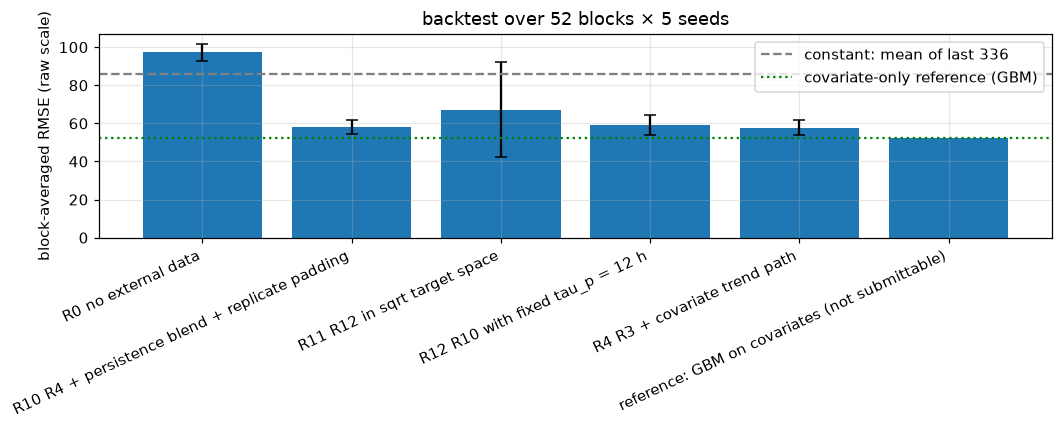

In [ ]:
# reference points on the same blocks: constant baselines
const = {"mean of last 336": np.mean([rmse(y[o:o + PRED_LEN], y[o - 336:o].mean()) for o in val_origins]),
         "global mean to date": np.mean([rmse(y[o:o + PRED_LEN], y[:o].mean()) for o in val_origins])}
print({k: round(v, 2) for k, v in const.items()})

fig, ax = plt.subplots(figsize=(10, 4))
order = summary.index.tolist()
ax.bar(range(len(order)), summary.loc[order, "rmse_mean"], yerr=summary.loc[order, "rmse_std"], capsize=4)
ax.axhline(const["mean of last 336"], c="gray", ls="--", label="constant: mean of last 336")
ax.axhline(ref.rmse.mean(), c="green", ls=":", label="covariate-only reference (GBM)")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=25, ha="right"); ax.set_ylabel("block-averaged RMSE (raw scale)")
ax.set_title(f"backtest over {len(val_origins)} blocks × {len(SEEDS)} seeds"); ax.legend()
plt.tight_layout(); plt.savefig(OUT / "fig_t2_08_ablation.pdf"); plt.show()

**How to read the table for the report.** Each row is one ablation arm; `rmse_std` is the spread across
seeds (requirement 3), the rows R0 versus R3–R6 are the required with/without-external-data comparison
(requirement 4; R0 vs R3–R6 here, all in the same raw target space), and `hidden_like_rmse` is the same comparison restricted to blocks whose horizon
conditions look like the hidden week. Pick the deployment configuration from this table, not from the
leaderboard.

best configuration on validation: R4 R3 + covariate trend path


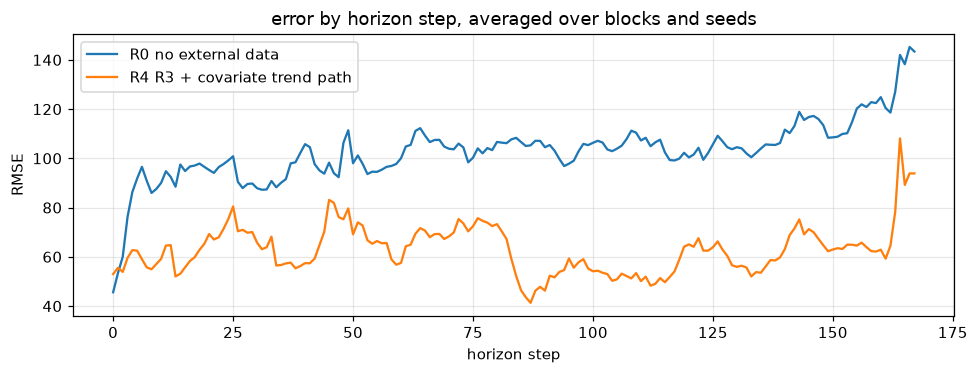

In [ ]:
# per-horizon error of the best arm vs the no-covariate arm: does conditioning help early, late, or both?
best_name = summary.drop(index=[i for i in summary.index if i.startswith("reference")]).rmse_mean.idxmin()
print("best configuration on validation:", best_name)
def horizon_curve(name):
    curves = []
    for seed in SEEDS:
        pred = preds[(name, seed)]
        err = np.stack([(pred[i] - y[o:o + PRED_LEN]) ** 2 for i, o in enumerate(val_origins)])
        curves.append(np.sqrt(err.mean(0)))
    return np.mean(curves, 0)
if True:
    none_name = next(c["name"] for c in CONFIGS if c["cov_mode"] == "none")
    hc_best, hc_none = horizon_curve(best_name), horizon_curve(none_name)
    plt.figure(figsize=(9, 3.5)); plt.plot(hc_none, label=none_name); plt.plot(hc_best, label=best_name)
    plt.xlabel("horizon step"); plt.ylabel("RMSE"); plt.legend(); plt.title("error by horizon step, averaged over blocks and seeds")
    plt.tight_layout(); plt.savefig(OUT / "fig_t2_09_horizon_error.pdf"); plt.show()

## 7. Final model: refit on the full history and forecast the hidden week

* The chosen configuration is refit on **all** training windows (origins up to `N − 168`) for the same
  number of epochs, once per seed, and the seed forecasts are averaged.
* `P` = sum of trainable parameters over the ensemble members, `E` = sum of their epochs — exactly what the
  leaderboard asks you to declare. The backtest epochs are *not* part of `E` because those models are not
  the ones producing the submitted forecast (they were selection runs on a holdout; the final models were
  trained once, from scratch). If your course staff interpret "early-stopped then refit" more strictly,
  add the selection epochs to `E` and say so in the report.

In [ ]:
# Selection rule: take the persistence-blend arm when it is within 3 RMSE of the best arm (differences below that are
# within seed/run variance, and the blend makes the first day of the forecast physically right); otherwise the best arm.
_blend = [c["name"] for c in CONFIGS if c.get("persist_blend")]
FINAL_NAME = best_name
if _blend:
    _best_blend = min(_blend, key=lambda n: summary.loc[n, "rmse_mean"])
    if summary.loc[_best_blend, "rmse_mean"] <= summary.loc[best_name, "rmse_mean"] + 3.0:
        FINAL_NAME = _best_blend
print("deployment configuration:", FINAL_NAME)
FINAL_SEEDS = [0, 1] if QUICK else list(range(10))   # ten members: penalty ~0.06, variance of the level halves
final_cfg = next(c for c in CONFIGS if c["name"] == FINAL_NAME)
full_origins = np.arange(SEQ_LEN, N - PRED_LEN + 1)
final_origin = np.array([N])                              # context = last 336 observed, decoder covariates cover the hidden week

forecasts, P_total, E_total = [], 0, 0
for seed in FINAL_SEEDS:
    model, cols = train_model(final_cfg, full_origins, seed, verbose=True)
    forecasts.append(predict(model, cols, final_cfg, final_origin, mask=(final_cfg["cov_mode"] == "hist"))[0])
    P_total += count_parameters(model); E_total += final_cfg["epochs"]
forecast = np.mean(forecasts, 0)
assert forecast.shape == (PRED_LEN,) and np.isfinite(forecast).all()
print(f"P = {P_total:,}   E = {E_total}   forecast mean {forecast.mean():.1f}  min {forecast.min():.1f}  max {forecast.max():.1f}")

deployment configuration: R10 R4 + persistence blend + replicate padding
  epoch 1/12  train loss 0.8078  (19s)
  epoch 2/12  train loss 0.4940  (38s)
  epoch 3/12  train loss 0.3875  (57s)
  epoch 4/12  train loss 0.3440  (76s)
  epoch 5/12  train loss 0.3125  (96s)
  epoch 6/12  train loss 0.2931  (115s)
  epoch 7/12  train loss 0.2782  (134s)
  epoch 8/12  train loss 0.2677  (153s)
  epoch 9/12  train loss 0.2595  (172s)
  epoch 10/12  train loss 0.2539  (191s)
  epoch 11/12  train loss 0.2512  (210s)
  epoch 12/12  train loss 0.2500  (229s)
  epoch 1/12  train loss 0.8237  (18s)
  epoch 2/12  train loss 0.5103  (37s)
  epoch 3/12  train loss 0.4030  (56s)
  epoch 4/12  train loss 0.3462  (76s)
  epoch 5/12  train loss 0.3100  (95s)
  epoch 6/12  train loss 0.2873  (113s)
  epoch 7/12  train loss 0.2721  (132s)
  epoch 8/12  train loss 0.2608  (150s)
  epoch 9/12  train loss 0.2524  (169s)
  epoch 10/12  train loss 0.2467  (188s)
  epoch 11/12  train loss 0.2438  (207s)
  epoch 12/1

In [ ]:
# ---- mixed ensemble: 10 x R10 (raw, already in `forecasts`) + 5 x R11 (sqrt), with a divergence guard
sqrt_cfg = next(c for c in CONFIGS if c["name"].startswith("R11"))
sqrt_fc, sqrt_loss = [], []
for seed in range(5):
    set_seed(seed)
    model, cols = build_model(sqrt_cfg); model.to(DEVICE)
    ds = WindowDataset(full_origins[::sqrt_cfg["stride"]], cols, SEQ_LEN, LABEL_LEN, PRED_LEN, space="sqrt")
    dl = torch.utils.data.DataLoader(ds, batch_size=sqrt_cfg["batch"], shuffle=True, drop_last=True)
    opt = torch.optim.AdamW(model.parameters(), lr=sqrt_cfg["lr"], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=sqrt_cfg["lr"], total_steps=sqrt_cfg["epochs"] * len(dl), pct_start=0.2)
    for ep in range(sqrt_cfg["epochs"]):
        model.train(); tot = 0.0
        for enc, dec, tgt in dl:
            enc, dec, tgt = enc.to(DEVICE), dec.to(DEVICE), tgt.to(DEVICE)
            loss = nn.MSELoss()(model(enc, dec), tgt)
            opt.zero_grad(set_to_none=True); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step()
            tot += loss.item() * len(enc)
    sqrt_loss.append(tot / len(ds)); sqrt_fc.append(predict(model, cols, sqrt_cfg, final_origin, mask=False)[0])
    print(f"sqrt member seed {seed}: final train loss {sqrt_loss[-1]:.4f}, forecast mean {sqrt_fc[-1].mean():.1f}")

keep = [i for i, l in enumerate(sqrt_loss) if l < 1.5 * np.median(sqrt_loss)]        # divergence guard
print("sqrt members kept:", keep)
mixed = np.mean(list(forecasts) + [sqrt_fc[i] for i in keep], 0)
P_mixed = P_total + 5 * count_parameters(model); E_mixed = E_total + 5 * sqrt_cfg["epochs"]   # all trained members counted
print(f"mixed forecast mean {mixed.mean():.1f} min {mixed.min():.1f} max {mixed.max():.1f} | P = {P_mixed:,}  E = {E_mixed}")
(OUT / "predictions_mixed.txt").write_text(", ".join(f"{v:.4f}" for v in mixed))

sqrt member seed 0: final train loss 0.2273, forecast mean 113.4
sqrt member seed 1: final train loss 0.2201, forecast mean 136.4
sqrt member seed 2: final train loss 0.2197, forecast mean 99.3
sqrt member seed 3: final train loss 0.2289, forecast mean 144.0
sqrt member seed 4: final train loss 0.2175, forecast mean 125.2
sqrt members kept: [0, 1, 2, 3, 4]
mixed forecast mean 123.1 min 5.8 max 285.2 | P = 388,855  E = 180


1594

In [ ]:
sqrt_only = np.mean(sqrt_fc, 0)
P_sqrt = 5 * 25923; E_sqrt = 5 * sqrt_cfg["epochs"]
print(f"sqrt-only forecast mean {sqrt_only.mean():.1f} min {sqrt_only.min():.1f} max {sqrt_only.max():.1f} | P = {P_sqrt:,}  E = {E_sqrt}")
(OUT / "predictions_sqrt.txt").write_text(", ".join(f"{v:.4f}" for v in sqrt_only))

sqrt-only forecast mean 123.6 min 5.6 max 294.6 | P = 129,615  E = 60


1595

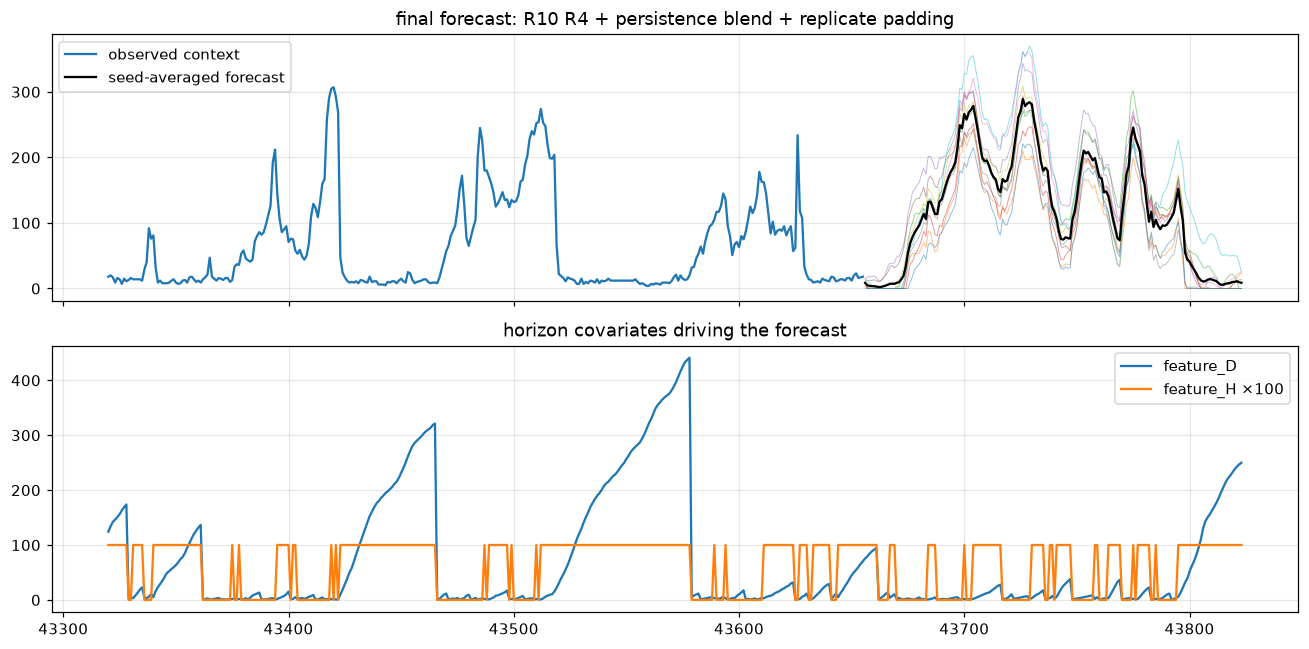

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ctx = np.arange(N - 336, N); hor = np.arange(N, N + PRED_LEN)
ax[0].plot(ctx, y[-336:], label="observed context"); 
for i, f_ in enumerate(forecasts): ax[0].plot(hor, f_, lw=.6, alpha=.5)
ax[0].plot(hor, forecast, c="k", lw=1.5, label="seed-averaged forecast"); ax[0].legend(); ax[0].set_title(f"final forecast: {FINAL_NAME}")
ax[1].plot(np.arange(N - 336, N + PRED_LEN), E[N - 336:N + PRED_LEN, 3], label="feature_D"); ax[1].plot(np.arange(N - 336, N + PRED_LEN), 100 * E[N - 336:N + PRED_LEN, 7], label="feature_H ×100"); ax[1].legend()
ax[1].set_title("horizon covariates driving the forecast"); plt.tight_layout(); plt.savefig(OUT / "fig_t2_10_final_forecast.pdf"); plt.show()

In [ ]:
submission = ", ".join(f"{v:.4f}" for v in forecast)
(OUT / "predictions.txt").write_text(submission)
pd.DataFrame({"time_idx": test.time_idx.values, "value": forecast}).to_csv(OUT / "predictions.csv", index=False)
json.dump({"config": FINAL_NAME, "seeds": FINAL_SEEDS, "P": int(P_total), "E": int(E_total),
           "quick_mode": QUICK, "backtest_blocks": int(len(val_origins))}, open(OUT / "declaration.json", "w"), indent=2)
print(f"168 values written to outputs/predictions.txt  (first: {forecast[0]:.2f} for time_idx 43657, last: {forecast[-1]:.2f} for time_idx 43824)")
print(f"declare on the leaderboard:  P = {P_total:,}   E = {E_total}")
print("last 6 observed:", y[-6:].round(1).tolist(), "| first 6 forecast:", forecast[:6].round(1).tolist(),
      "  <- these should be of similar magnitude")
print(submission[:120], "...")

168 values written to outputs/predictions.txt  (first: 8.51 for time_idx 43657, last: 8.76 for time_idx 43824)
declare on the leaderboard:  P = 259,240   E = 120
last 6 observed: [12.0, 20.0, 23.0, 16.0, 17.0, 18.0] | first 6 forecast: [8.5, 4.800000190734863, 4.0, 3.5, 3.5, 2.799999952316284]   <- these should be of similar magnitude
8.5148, 4.8347, 4.0391, 3.4646, 3.5022, 2.7999, 2.1942, 2.3243, 3.1820, 4.2017, 5.7055, 7.1533, 7.2595, 7.1508, 8.5951,  ...
